# SPY Data — First Look EDA

Quick exploratory analysis of the processed SPY surface-point data.

**Prerequisites**: Run the pipeline steps first:
```bash
cd src/data
python 01_ingest_spy_github_dataset.py
python 02_inspect_spy_schema.py
python 03_build_spy_surface_table.py
```

In [3]:
import os
import sys
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


def _resolve_project_root() -> pathlib.Path:
    """Find repo root reliably regardless of notebook working directory."""
    cwd = pathlib.Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "src" / "data" / "config.py").exists():
            return p
    return cwd


PROJECT_ROOT = _resolve_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "data"))

from config import SURFACE_POINTS_FILE, SURFACE_POINTS_STRICT_FILE, PLOTS_DIR

# Allow manual override when running from a non-standard environment.
SURFACE_OVERRIDE = os.environ.get("SPY_SURFACE_FILE", "").strip()

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SURFACE_POINTS_FILE:", SURFACE_POINTS_FILE, "exists=", SURFACE_POINTS_FILE.exists())
print("SURFACE_POINTS_STRICT_FILE:", SURFACE_POINTS_STRICT_FILE, "exists=", SURFACE_POINTS_STRICT_FILE.exists())
if SURFACE_OVERRIDE:
    print("SPY_SURFACE_FILE override:", SURFACE_OVERRIDE)

PROJECT_ROOT: /Users/mengziyue/Neural IV Surface inference
SURFACE_POINTS_FILE: /Users/mengziyue/Neural IV Surface inference/data_processed/spy/spy_surface_points.parquet exists= False
SURFACE_POINTS_STRICT_FILE: /Users/mengziyue/Neural IV Surface inference/data_processed/spy/spy_surface_points_strict.parquet exists= False


In [4]:
# Load processed data
surface_path = None

if SURFACE_OVERRIDE:
    override_path = pathlib.Path(SURFACE_OVERRIDE)
    if override_path.exists():
        surface_path = override_path
    else:
        raise FileNotFoundError(f"SPY_SURFACE_FILE does not exist: {override_path}")
elif SURFACE_POINTS_FILE.exists():
    surface_path = SURFACE_POINTS_FILE
elif SURFACE_POINTS_STRICT_FILE.exists():
    # Fallback: strict file still supports most EDA sections.
    surface_path = SURFACE_POINTS_STRICT_FILE
    print("[warning] Conservative parquet not found; falling back to strict parquet.")

if surface_path is not None:
    df = pd.read_parquet(surface_path)
    print(f"Loaded dataset: {surface_path}")
else:
    # Demo fallback so notebook remains runnable when data files are absent locally.
    print("[warning] No processed parquet found. Using synthetic demo dataset.")
    rng = np.random.default_rng(42)
    n = 10000
    dates = pd.date_range("2020-01-02", periods=50, freq="B")
    date_col = rng.choice(dates, size=n)
    tau = rng.uniform(1 / 365, 2.0, size=n)
    log_m = rng.uniform(-0.6, 0.6, size=n)
    iv_clean = np.clip(0.2 + 0.1 * np.abs(log_m) + rng.normal(0, 0.01, size=n), 0.01, 1.5)
    observed = rng.random(n) < 0.4
    iv_obs = iv_clean.copy()
    iv_obs[observed] = np.clip(iv_obs[observed] + rng.normal(0, 0.02, size=observed.sum()), 1e-4, 2.0)
    bid = np.clip(iv_obs * 100 * 0.95, 0.01, None)
    ask = np.clip(iv_obs * 100 * 1.05, bid + 1e-6, None)
    mid = (bid + ask) / 2
    df = pd.DataFrame({
        "date": pd.to_datetime(date_col),
        "type": rng.choice(["call", "put"], size=n),
        "strike": 100 * np.exp(log_m),
        "spot": np.full(n, 100.0),
        "bid": bid,
        "ask": ask,
        "mid": mid,
        "volume": rng.integers(0, 1000, size=n),
        "open_interest": rng.integers(0, 5000, size=n),
        "implied_volatility": iv_obs,
        "tau": tau,
        "log_moneyness": log_m,
        "flag_zero_bid": bid <= 1e-8,
        "flag_zero_volume": False,
        "flag_zero_oi": False,
        "flag_wide_spread": ((ask - bid) / np.maximum(mid, 1e-8)) > 0.5,
    })

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

[warning] No processed parquet found. Using synthetic demo dataset.
Rows: 10,000
Columns: ['date', 'type', 'strike', 'spot', 'bid', 'ask', 'mid', 'volume', 'open_interest', 'implied_volatility', 'tau', 'log_moneyness', 'flag_zero_bid', 'flag_zero_volume', 'flag_zero_oi', 'flag_wide_spread']


,date,type,strike,spot,bid,ask,mid,volume,open_interest,implied_volatility,tau,log_moneyness,flag_zero_bid,flag_zero_volume,flag_zero_oi,flag_wide_spread
0,2020-01-08,call,83.282310,100.0,19.767849,21.848675,20.808262,196,2014,0.208083,0.438440,-0.182934,False,False,False,False
1,2020-02-25,call,62.087140,100.0,22.954166,25.370394,24.162280,354,4491,0.241623,1.326779,-0.476631,False,False,False,False
2,2020-02-17,call,78.858282,100.0,21.763658,24.054569,22.909114,613,186,0.229091,1.534362,-0.237518,False,False,False,False
3,2020-01-31,put,144.491085,100.0,22.473808,24.839472,23.656640,599,4526,0.236566,0.335555,0.368048,False,False,False,False
4,2020-01-31,call,99.220597,100.0,18.620991,20.581095,19.601043,331,2377,0.196010,0.090336,-0.007825,False,False,False,False


## 1. Row Counts by Year

**What we're doing here**
- Plot yearly row counts of processed SPY option observations to verify data coverage over time.

**Why this is important**
- Stable and broad temporal coverage is required before trusting any reconstruction benchmark.
- Gaps or sharp drops can bias train/val/test behavior and model diagnostics.

**What we observed**
- Interpret the bar chart for coverage consistency, structural breaks, and anomalous years.
- Note any low-coverage periods that may need separate handling in experiments.

**How this contributes to the end goal**
- Our end goal is a decision-grade IV surface inference system from sparse/noisy quotes.
- Coverage quality is a foundation for reliable pricing/hedging/risk-oriented surface recovery.

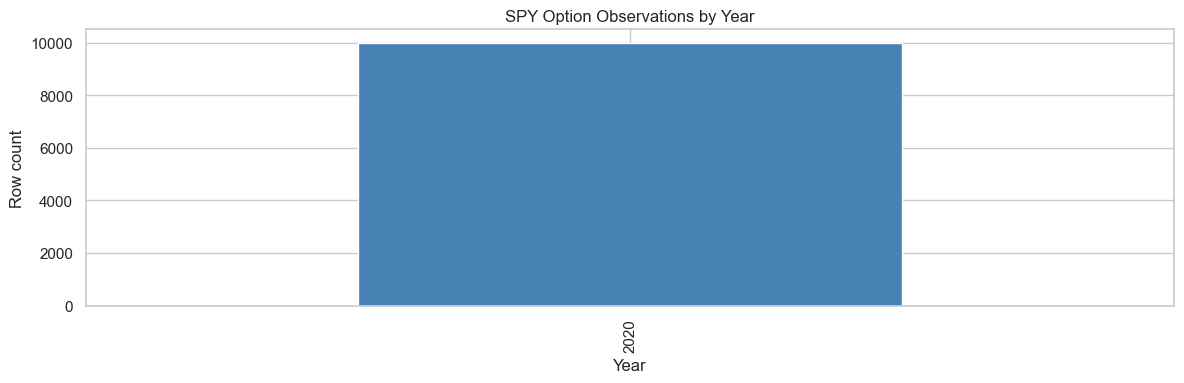

year
2020    10000
dtype: int64

In [5]:
df["year"] = df["date"].dt.year
year_counts = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 4))
year_counts.plot.bar(ax=ax, color="steelblue")
ax.set_title("SPY Option Observations by Year")
ax.set_ylabel("Row count")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_rows_by_year.png", dpi=150)
plt.show()

year_counts

## 2. Call vs Put Split

**What we're doing here**
- Summarize call vs put observation counts in the processed dataset.

**Why this is important**
- Call/put composition affects moneyness-region representation and can influence reconstruction difficulty.
- Severe imbalance may distort error interpretation by region.

**What we observed**
- Use the printed counts and ratio to check whether one side dominates.
- Flag strong asymmetry for later robustness checks.

**How this contributes to the end goal**
- Balanced market-state coverage helps us infer more reliable latent surface structure.
- This supports downstream usability for pricing, hedging, and risk monitoring.

In [6]:
type_counts = df["type"].str.lower().value_counts()
print(type_counts)
print(f"\nCall/Put ratio: {type_counts.get('call', 0) / max(type_counts.get('put', 1), 1):.2f}")

type
put     5038
call    4962
Name: count, dtype: int64

Call/Put ratio: 0.98


## 3. Implied Volatility Distribution

**What we're doing here**
- Visualize the overall and zoomed implied-volatility distributions.

**Why this is important**
- Distribution shape reveals noise level, tail behavior, and potential cleaning issues.
- Extreme or multimodal patterns can indicate modeling challenges.

**What we observed**
- Check central mass, skewness, and tail heaviness in both full and zoomed views.
- Identify whether value ranges align with realistic SPY IV behavior.

**How this contributes to the end goal**
- Understanding IV distribution helps choose robust baselines and diagnostics.
- It directly supports stable surface inference under sparse/noisy inputs.

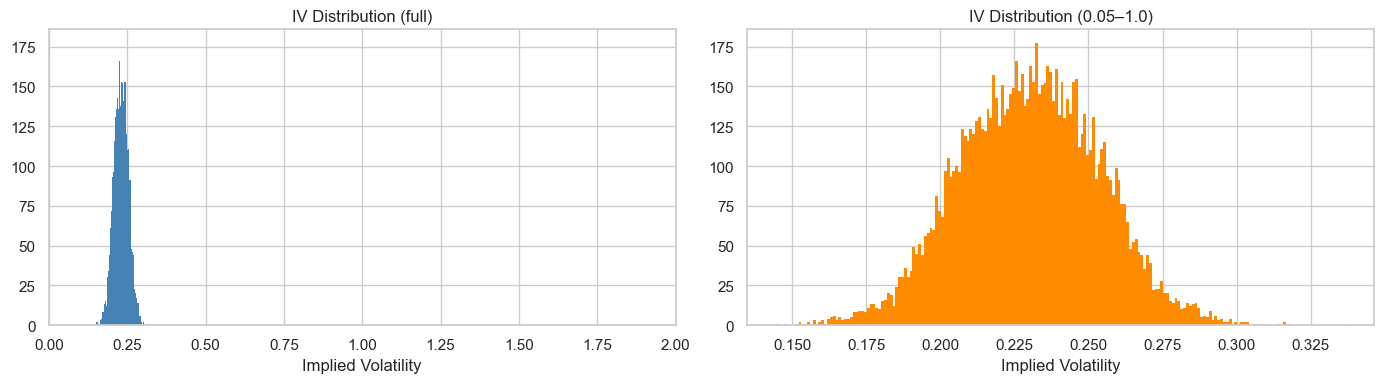

count    10000.000000
mean         0.230236
std          0.023596
min          0.144418
25%          0.213542
50%          0.230528
75%          0.246528
max          0.336763
Name: implied_volatility, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["implied_volatility"], bins=200, color="steelblue", edgecolor="none")
axes[0].set_title("IV Distribution (full)")
axes[0].set_xlabel("Implied Volatility")
axes[0].set_xlim(0, 2)

# Zoom into typical range
mask = df["implied_volatility"].between(0.05, 1.0)
axes[1].hist(df.loc[mask, "implied_volatility"], bins=200, color="darkorange", edgecolor="none")
axes[1].set_title("IV Distribution (0.05–1.0)")
axes[1].set_xlabel("Implied Volatility")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_iv_distribution.png", dpi=150)
plt.show()

df["implied_volatility"].describe()

## 4. Tau (Time to Expiry) Distribution

**What we're doing here**
- Plot the maturity (`tau`) distribution for processed options.

**Why this is important**
- Maturity coverage strongly affects term-structure reconstruction quality.
- Underrepresentation at short/long maturities creates harder extrapolation zones.

**What we observed**
- Assess where density concentrates and whether maturity tails are sparse.
- Note maturity regions that may need targeted evaluation slices.

**How this contributes to the end goal**
- Term-structure reliability is essential for decision-grade IV surfaces.
- This informs where model uncertainty and error are likely highest for risk usage.

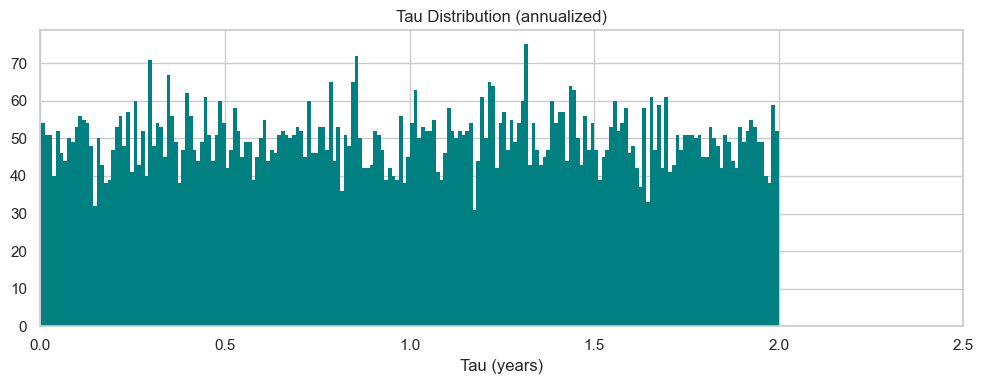

count    10000.000000
mean         1.001615
std          0.573500
min          0.002766
25%          0.500996
50%          1.011321
75%          1.489994
max          1.999954
Name: tau, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["tau"], bins=200, color="teal", edgecolor="none")
ax.set_title("Tau Distribution (annualized)")
ax.set_xlabel("Tau (years)")
ax.set_xlim(0, 2.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_tau_distribution.png", dpi=150)
plt.show()

df["tau"].describe()

## 5. Log-Moneyness Distribution

**What we're doing here**
- Plot the `log_moneyness` distribution to inspect strike/spot coverage.

**Why this is important**
- Surface quality often degrades in deep ITM/OTM regions with sparse observations.
- Moneyness imbalance can hide where reconstruction errors originate.

**What we observed**
- Examine concentration around ATM vs tail regions.
- Identify whether wings are sufficiently represented for robust diagnostics.

**How this contributes to the end goal**
- A reliable inference system must recover useful structure across moneyness regions, not only near ATM.
- This is key for pricing and risk in tail scenarios.

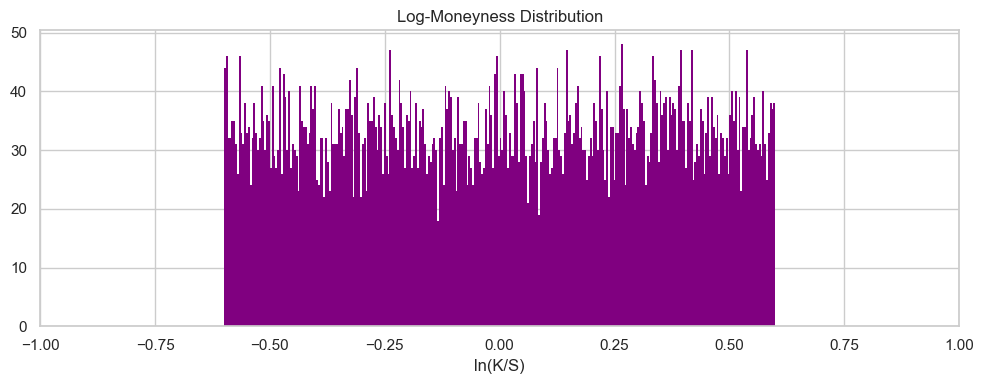

count    10000.000000
mean         0.002682
std          0.348574
min         -0.599977
25%         -0.299874
50%          0.006519
75%          0.307794
max          0.599979
Name: log_moneyness, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["log_moneyness"], bins=300, color="purple", edgecolor="none")
ax.set_title("Log-Moneyness Distribution")
ax.set_xlabel("ln(K/S)")
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_log_moneyness_distribution.png", dpi=150)
plt.show()

df["log_moneyness"].describe()

## 6. IV Surface — Sample Dates

**What we're doing here**
- Visualize point-cloud surface slices (`tau` vs `log_moneyness`, color = IV) on representative dates.

**Why this is important**
- This gives a direct sanity check of smile/skew/term-structure geometry.
- It reveals whether the data supports meaningful surface reconstruction on individual dates.

**What we observed**
- Inspect qualitative shape differences across dates and identify sparse/noisy regions.
- Note dates or regions where geometry appears unstable or thin.

**How this contributes to the end goal**
- Date-level geometric consistency is central to inferring a usable latent surface state.
- It supports robust reconstruction for downstream pricing/hedging/risk decisions.

[warning] Strict parquet not found; using loaded dataset for surface samples.


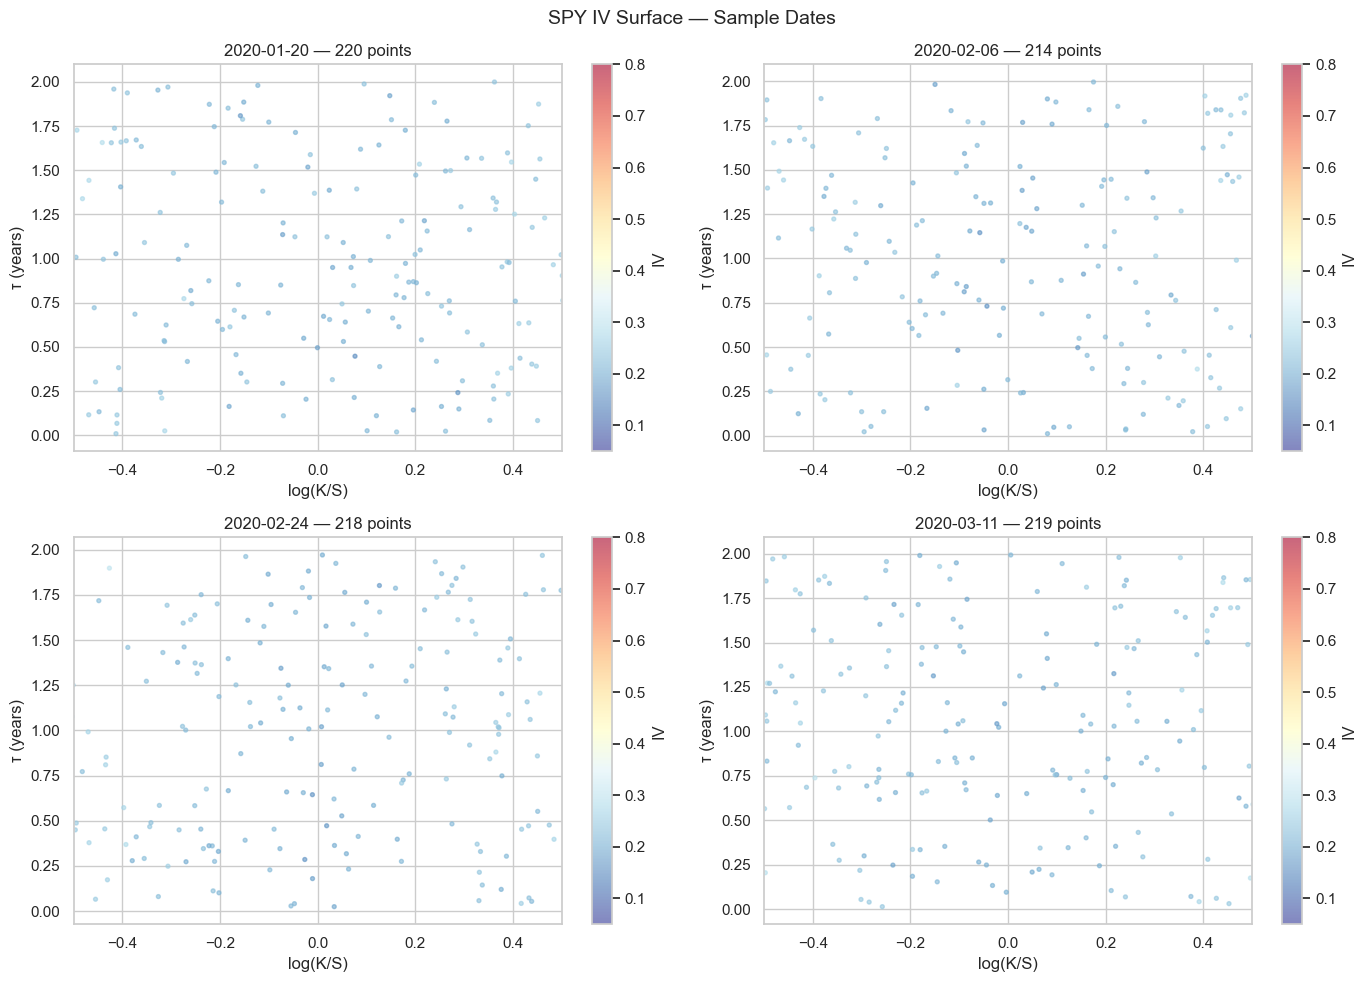

In [10]:
# Pick a few well-spaced sample dates
unique_dates = sorted(df["date"].unique())
n = len(unique_dates)
sample_indices = [n // 4, n // 2, 3 * n // 4, n - 1]
sample_dates = [unique_dates[i] for i in sample_indices]

# Prefer strict subset for cleaner plots, but fallback to current df if unavailable.
if SURFACE_POINTS_STRICT_FILE.exists():
    strict = pd.read_parquet(SURFACE_POINTS_STRICT_FILE)
else:
    strict = df.copy()
    print("[warning] Strict parquet not found; using loaded dataset for surface samples.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, d in zip(axes.flat, sample_dates):
    sub = strict[strict["date"] == d]
    if len(sub) == 0:
        ax.set_title(f"{str(d)[:10]} — no data")
        continue
    sc = ax.scatter(
        sub["log_moneyness"], sub["tau"],
        c=sub["implied_volatility"], cmap="RdYlBu_r",
        s=8, alpha=0.6, vmin=0.05, vmax=0.8,
    )
    ax.set_xlabel("log(K/S)")
    ax.set_ylabel("τ (years)")
    ax.set_title(f"{str(d)[:10]} — {len(sub):,} points")
    ax.set_xlim(-0.5, 0.5)
    plt.colorbar(sc, ax=ax, label="IV")

plt.suptitle("SPY IV Surface — Sample Dates", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_iv_surface_samples.png", dpi=150)
plt.show()

## 7. Spread Diagnostics

**What we're doing here**
- Examine absolute and relative bid-ask spread distributions and quality flags.

**Why this is important**
- Spread behavior is a direct proxy for quote quality and liquidity stress.
- High-spread regions can inject noise and destabilize reconstruction metrics.

**What we observed**
- Use histograms and flag counts to identify noisy/illiquid portions of the dataset.
- Track whether flagged fractions are manageable or require stricter filtering.

**How this contributes to the end goal**
- Better quote-quality awareness improves trust in inferred surfaces.
- This is necessary for decision-grade outputs used in pricing and risk monitoring.

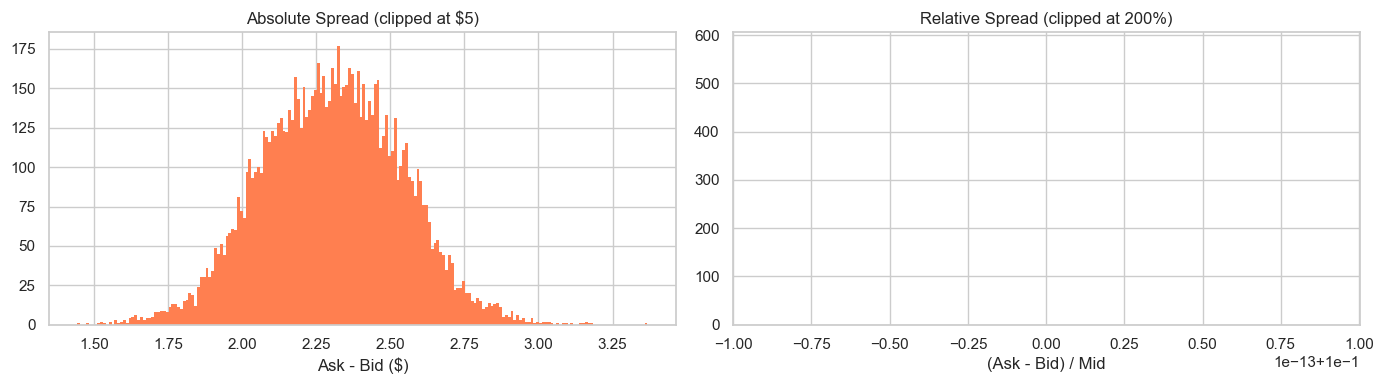

Flag summary:
  flag_zero_bid: 0 (0.0%)
  flag_zero_volume: 0 (0.0%)
  flag_zero_oi: 0 (0.0%)
  flag_wide_spread: 0 (0.0%)


In [11]:
spread = (df["ask"] - df["bid"])
rel_spread = spread / np.maximum(df["mid"], 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(spread.clip(0, 5), bins=200, color="coral", edgecolor="none")
axes[0].set_title("Absolute Spread (clipped at $5)")
axes[0].set_xlabel("Ask - Bid ($)")

axes[1].hist(rel_spread.clip(0, 2), bins=200, color="coral", edgecolor="none")
axes[1].set_title("Relative Spread (clipped at 200%)")
axes[1].set_xlabel("(Ask - Bid) / Mid")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "spy_spread_diagnostics.png", dpi=150)
plt.show()

print("Flag summary:")
for col in ["flag_zero_bid", "flag_zero_volume", "flag_zero_oi", "flag_wide_spread"]:
    print(f"  {col}: {df[col].sum():,} ({df[col].mean()*100:.1f}%)")

## 8. Missingness Diagnostics

**What we're doing here**
- Quantify column-wise missingness percentages in the processed dataset.

**Why this is important**
- Missingness can silently bias benchmark construction and model evaluation.
- Understanding null structure is necessary for reliable preprocessing assumptions.

**What we observed**
- Review which fields (if any) are incomplete and their null rates.
- Identify whether missingness is negligible or requires explicit handling.

**How this contributes to the end goal**
- Clean, well-characterized inputs are required for stable latent surface inference.
- This improves reliability of downstream pricing/hedging/risk applications.

In [12]:
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]

if len(null_pct) == 0:
    print("No missing values in the processed dataset.")
else:
    print("Columns with missing values (%):\n")
    print(null_pct.to_string())

No missing values in the processed dataset.


## 9. Summary Stats — Strict Subset

**What we're doing here**
- Compare conservative vs strict dataset sizes and summarize strict-set ranges (date, IV, tau, log-moneyness).

**Why this is important**
- The strict subset defines the core modeling domain for benchmark tasks.
- Its coverage/range determines what the model is expected to reconstruct reliably.

**What we observed**
- Use the printed stats to verify strict-set size, date span, and value bounds.
- Confirm ranges are consistent with Phase 1 assumptions and cleaning rules.

**How this contributes to the end goal**
- A well-defined strict domain improves reproducibility and comparability across baselines.
- This supports the end-goal pipeline toward decision-grade IV surface inference.

In [13]:
print(f"Conservative: {len(df):,} rows")
print(f"Strict:       {len(strict):,} rows ({len(strict)/len(df)*100:.1f}%)")
print(f"\nStrict date range: {strict['date'].min().date()} → {strict['date'].max().date()}")
print(f"Unique dates:      {strict['date'].nunique():,}")
print(f"\nStrict IV:  [{strict['implied_volatility'].min():.4f}, {strict['implied_volatility'].max():.4f}]")
print(f"Strict tau: [{strict['tau'].min():.4f}, {strict['tau'].max():.4f}]")
print(f"Strict lnK/S: [{strict['log_moneyness'].min():.4f}, {strict['log_moneyness'].max():.4f}]")

Conservative: 10,000 rows
Strict:       10,000 rows (100.0%)

Strict date range: 2020-01-02 → 2020-03-11
Unique dates:      50

Strict IV:  [0.1444, 0.3368]
Strict tau: [0.0028, 2.0000]
Strict lnK/S: [-0.6000, 0.6000]
